# Lidar autoencoder - harom architektura osszehasonlitasa

Harom modell tanul UGYANAZON az adaton. Mindharom TERBELI jellemzoterkepet
ad (nem lapitott vektort) - az RL sajat CNN feature-extractora dolgozza fel:

| modell | bemenet | mit tanul |
|---|---|---|
| `bev_ae` | nyers pontfelho | fix BEV statisztika (occupancy + z_max/z_min) -> conv AE |
| `graph_ae` | range image | dinamikus graf-konvolucio (EdgeConv) |
| `point_mae` | nyers pontfelho | maszkolt patch-rekonstrukcio (Transformer) |

## 1. Modulok, beallitasok

In [1]:
import gc
import glob
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

from lidar.point_mae import PointMAE
from lidar.bev_ae import BEVConvAE
from lidar.graph_ae import LidarAE, DDCONFIG, points_to_range_image

DATA_DIR = "dataset/lidar"
EPOCHS = 30
N_FRAMES = None           # None = minden frame

N_POINTS = 24576

BATCH = {"bev_ae": 768, "graph_ae": 32, "point_mae": 192}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

print(DEVICE, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")
if torch.cuda.is_available():
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

cuda NVIDIA GeForce RTX 4070 Laptop GPU
VRAM: 8.3 GB


In [2]:
def free_vram(*objects):
    for o in objects:
        if hasattr(o, "cpu"):
            o.cpu()
        del o
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def vram():
    """Aktualis GPU memoriahasznalat."""
    if not torch.cuda.is_available():
        return "n/a"
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    return (f"{torch.cuda.memory_allocated() / 1e9:.2f} GB foglalt / "
            f"{torch.cuda.memory_reserved() / 1e9:.2f} GB fenntartva / "
            f"{total:.1f} GB osszes")


print("indulaskor:", vram())

indulaskor: 0.00 GB foglalt / 0.00 GB fenntartva / 8.3 GB osszes


## 2. Adatok betoltese

**Harmas vagas (70 / 15 / 15), a szokasos szereposztassal:**

| halmaz | mire valo | ki latja |
|---|---|---|
| **train** | a sulyok tanulasa | a gradiens |
| **val** | early stopping, a legjobb epoch kivalasztasa | a DONTESEINK |
| **test** | a vegso, elfogulatlan meres | **csak egyszer, a legvegen** |

In [3]:
PATHS = sorted(glob.glob(os.path.join(DATA_DIR, "*.npy")))
if N_FRAMES:
    PATHS = PATHS[:N_FRAMES]

# A keveres KOTELEZO: a framek idorendben keszultek, vagas elott a val/test
# a felvetel utolso szakasza lenne - mas utszakasz, mas forgalom, mint a train.
PERM = np.random.default_rng(0).permutation(len(PATHS))

VAL_FRAC, TEST_FRAC = 0.15, 0.15
N_TEST = int(len(PATHS) * TEST_FRAC)
N_VAL = int(len(PATHS) * VAL_FRAC)
N_TRAIN = len(PATHS) - N_VAL - N_TEST

print(f"{len(PATHS)} frame   train {N_TRAIN}   val {N_VAL}   test {N_TEST}")
print(f"RAM egy reprezentaciora: pontfelho "
      f"{len(PATHS) * N_POINTS * 3 * 4 / 1e9:.1f} GB, "
      f"range image {len(PATHS) * 64 * 512 * 4 / 1e9:.1f} GB")

50051 frame   train 35037   val 7507   test 7507
RAM egy reprezentaciora: pontfelho 14.8 GB, range image 6.6 GB


In [4]:
def _load(shape, fill, which=("train", "val"), workers=16):
    from concurrent.futures import ThreadPoolExecutor

    # A permutacio elso N_TEST eleme a test, utana N_VAL a val, a tobbi train.
    spans = {"test": (0, N_TEST),
             "val": (N_TEST, N_TEST + N_VAL),
             "train": (N_TEST + N_VAL, len(PATHS))}

    out = []
    for name in which:
        lo, hi = spans[name]
        idx = PERM[lo:hi]
        arr = np.empty((len(idx), *shape), dtype=np.float32)

        def read_one(k):
            arr[k] = fill(np.load(PATHS[idx[k]]), idx[k])

        with ThreadPoolExecutor(max_workers=workers) as ex:
            list(tqdm(ex.map(read_one, range(len(idx))), total=len(idx),
                      desc=f"{name:5s}", unit="frame"))
        out.append(torch.from_numpy(arr))
    return out


def load_clouds(which=("train", "val")):
    def fill(pts, idx):
        sel = np.random.default_rng(idx).choice(
            len(pts), N_POINTS, replace=len(pts) < N_POINTS)
        return pts[sel]
    return _load((N_POINTS, 3), fill, which)


def load_ranges(which=("train", "val")):
    # Az alakot a fuggvenytol kerdezzuk, nem beegetve: a TopoLiDM config
    # 64x1024-et ir elo, de ha ez valtozik, ez a cella nem szall el.
    shape = points_to_range_image(np.load(PATHS[0])).shape
    return _load(shape, lambda pts, idx: points_to_range_image(pts), which)


def drop(*names):
    """Tenzorok eldobasa a RAM-bol. A `del` utan a gc szabaditja fel."""
    for n in names:
        globals().pop(n, None)
    gc.collect()

### Mit tanulunk?

Harom veletlen frame, haromfele nezetben - pontosan az, amit a modellek
bemenetkent kapnak. Ehhez ideiglenesen betoltunk nehany frame-et.

In [ ]:
# Csak a megjelenitendo framek - nem a teljes adat.
SHOW_IDX = sorted(np.random.default_rng(1).choice(len(PATHS), 3, replace=False))
_show_raw = [np.load(PATHS[i]) for i in SHOW_IDX]
_show_pts = [torch.from_numpy(
    a[np.random.default_rng(i).choice(len(a), N_POINTS,
                                      replace=len(a) < N_POINTS)].astype(np.float32))
    for i, a in zip(SHOW_IDX, _show_raw)]

# A BEV statisztika fix keplet, nem tanult jellemzoterkep - egy friss
# modellpeldany is a vegleges kepet adja.
_probe = BEVConvAE().eval()
print(f"BEV racs {_probe.grid_h}x{_probe.grid_w}, "
      f"{_probe.hparams.voxel_size} m cella   |   framek: {SHOW_IDX}")

fig, axes = plt.subplots(3, 3, figsize=(17, 13))
for row, (idx, raw, pts) in enumerate(zip(SHOW_IDX, _show_raw, _show_pts)):
    frame = pts.numpy()

    ax = axes[row, 0]
    ax.scatter(frame[:, 0], frame[:, 1], c=frame[:, 2], s=0.3, cmap="viridis",
               vmin=-3, vmax=4, linewidths=0)
    ax.scatter([0], [0], c="red", s=40, marker="^")
    ax.set_xlim(-50, 50)
    ax.set_ylim(-50, 50)
    ax.set_aspect("equal")
    ax.set_ylabel(f"frame {idx}\ny [m]")
    if row == 0:
        ax.set_title(f"pontfelho ({len(frame)} / {len(raw)} pont)\npoint_mae",
                     fontsize=11)

    ax = axes[row, 1]
    with torch.no_grad():
        occ = _probe.to_bev(pts.unsqueeze(0))[0, 0].numpy()
    _r = _probe.hparams.pc_range          # a modell sajat hatosugara
    ax.imshow(occ, cmap="gray_r", origin="lower", extent=[-_r, _r, -_r, _r])
    ax.set_xlabel("x [m]")
    if row == 0:
        ax.set_title("BEV occupancy (3 csatornabol)\nbev_ae", fontsize=11)
    ax.text(0.02, 0.96, f"{100 * occ.mean():.0f}% cella", transform=ax.transAxes,
            fontsize=9, va="top")

    ax = axes[row, 2]
    ri = points_to_range_image(raw)[0]
    ax.imshow(ri, cmap="magma", aspect="auto", vmin=-1, vmax=1)
    ax.set_xlabel("azimut (512 oszlop)")
    ax.set_ylabel("csatorna (64 sor)")
    if row == 0:
        ax.set_title("range image\ngraph_ae", fontsize=11)
    ax.text(0.02, 0.95, f"{100 * (ri > -0.999).mean():.0f}% kitoltott",
            transform=ax.transAxes, color="white", fontsize=9, va="top")

plt.tight_layout()
plt.show()
free_vram(_probe)
drop("_show_raw")

### Interaktiv 3D nezet

Forgathato, nagyithato. Ez a NYERS pontfelho — amibol mindharom modell
bemenete keszul.

In [ ]:
def show_3d(pts, title="", max_points=25000, size=1.2, extra=None,
            height=650):
    pts = pts.cpu().numpy() if hasattr(pts, "cpu") else np.asarray(pts)

    # Ritkitas, hogy a bongeszo ne akadjon meg.
    if len(pts) > max_points:
        sel = np.random.default_rng(0).choice(len(pts), max_points, replace=False)
        pts = pts[sel]

    traces = [go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode="markers",
        marker=dict(size=size, color=pts[:, 2], colorscale="Viridis",
                    cmin=-3, cmax=4, opacity=0.85,
                    colorbar=dict(title="z [m]", thickness=12, len=0.6)),
        name=f"pontfelho ({len(pts)})",
        hovertemplate="x %{x:.1f}<br>y %{y:.1f}<br>z %{z:.1f}<extra></extra>",
    )]

    # Az auto helye: a lidar az origoban van (x=0, z=2.4 a szenzor magassaga,
    # de a pontok mar a szenzorhoz kepest vannak megadva).
    traces.append(go.Scatter3d(
        x=[0], y=[0], z=[0], mode="markers",
        marker=dict(size=6, color="red", symbol="diamond"),
        name="ego (lidar)", hoverinfo="name"))

    for e_pts, e_name, e_color, e_size in (extra or []):
        e_pts = e_pts.cpu().numpy() if hasattr(e_pts, "cpu") else np.asarray(e_pts)
        traces.append(go.Scatter3d(
            x=e_pts[:, 0], y=e_pts[:, 1], z=e_pts[:, 2], mode="markers",
            marker=dict(size=e_size, color=e_color), name=e_name))

    fig = go.Figure(traces)
    fig.update_layout(
        title=title,
        height=height,
        margin=dict(l=0, r=0, t=40 if title else 0, b=0),
        legend=dict(x=0, y=1),
        scene=dict(
            # aspectmode="data": a harom tengely ARANYA a valos meretekbol
            # jon. Enelkul a plotly kockara nyujtja a jelenetet, es a lapos
            # ut-sik magasnak tunne.
            aspectmode="data",
            xaxis_title="x [m]  (elore)",
            yaxis_title="y [m]  (balra)",
            zaxis_title="z [m]  (fel)",
            # Kezdo kameraallas: kicsit hatulrol-felulrol, mint egy
            # kovetokamera - igy egybol felismerheto a jelenet.
            camera=dict(eye=dict(x=-1.4, y=-1.4, z=0.9)),
        ),
    )
    fig.show()

In [7]:
# Ugyanaz a harom frame 3D-ben, forgathatoan.
for idx, pts in zip(SHOW_IDX, _show_pts):
    show_3d(pts, title=f"frame {idx} - nyers pontfelho")

## 3. Kozos tanito fuggvenyek

A `train_model` **megszakithato es folytathato**: minden epoch vegen ment
(atomikusan, `.tmp` + atnevezes), es ujrainditaskor onnan folytatja, ahol
abbahagyta. Az optimizer allapota is mentodik — enelkul a folytatas nulla
lendulettel indulna, es az elso par epoch elrontana a tanulast.

In [ ]:
def evaluate(model, data, batch, parts=False):
    """Atlagos loss a teljes adathalmazon.

    parts=True : (loss, dict) - a modell sajat diagnosztikaja is, atlagolva.
        EZ FONTOS: mindharom modellnel elofordult, hogy a loss szepen csokkent,
        kozben a modell mast tanult meg, mint amit akartunk:

          bev_ae     a loss 0.021-en allt, de az occupancy IoU csak 0.58 volt
                     (precision 0.59 - felmillio cella tevesen foglalt)
          point_mae  a Chamfer 4.74, a trivialis patch-atlag 4.79 -> a modell
                     KOLLAPSZALT, minden patch-re kb. ugyanazt adta
          graph_ae   az L1 nagy reszet az URES teruletek tettek ki

        Egyetlen szambol ezek egyike sem latszik.
    """
    model.eval()
    total, n, acc = 0.0, 0, {}
    with torch.no_grad():
        for i in range(0, len(data), batch):
            xb = data[i:i + batch].to(DEVICE, non_blocking=True).float()
            if parts:
                loss, p = model.loss(xb, parts=True)
                for k, v in p.items():
                    acc[k] = acc.get(k, 0.0) + v * len(xb)
            else:
                loss = model.loss(xb)
            total += float(loss) * len(xb)
            n += len(xb)
    if not parts:
        return total / n
    return total / n, {k: v / n for k, v in acc.items()}


def train_model(model, label, batch, train_data, val_data,
                epochs=EPOCHS, lr=1e-3, patience=5, sched="plateau",
                resume=True):
    model = model.to(DEVICE)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    if sched == "plateau":
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.5, patience=2, min_lr=lr / 100)
    elif sched == "cosine":
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=epochs, eta_min=lr / 100)
    else:
        sched = None

    hist = {"label": label, "arch": type(model).__name__,
            "train": [], "val": [], "best": float("inf"),
            "params": sum(p.numel() for p in model.parameters()),
            "ckpt": f"lidar/{label}.ckpt"}
    best_state, bad, start_ep = None, 0, 1

    # --- FOLYTATAS a mentett checkpointbol -----------------------------
    if resume and os.path.exists(hist["ckpt"]):
        ck = torch.load(hist["ckpt"], map_location="cpu", weights_only=False)
        # Csak akkor folytatunk, ha UGYANARROL a modellrol van szo. Ha kozben
        # atirtad az architekturat, a sulyok alakja nem egyezne - olyankor
        # inkabb elolrol kezdunk, mint hogy hibaval elszalljon.
        if ck.get("arch") == hist["arch"] and "epoch" in ck:
            try:
                model.load_state_dict(ck["state_dict"])
                opt.load_state_dict(ck["optimizer"])
                if sched is not None and ck.get("sched") is not None:
                    sched.load_state_dict(ck["sched"])
                hist["train"] = list(ck.get("train", []))
                hist["val"] = list(ck.get("val", []))
                hist["best"] = ck.get("best_val", float("inf"))
                best_state = ck.get("best_state", ck["state_dict"])
                bad = ck.get("bad", 0)
                start_ep = ck["epoch"] + 1
                if start_ep > epochs:
                    print(f"{label}: mar lefutott {ck['epoch']} epoch "
                          f"(best val {hist['best']:.5f}). Emeld az `epochs` "
                          f"erteket, vagy add at a resume=False-t az "
                          f"ujrakezdeshez.")
                    model.load_state_dict(best_state)
                    hist["epochs_run"] = len(hist["train"])
                    hist["time"] = 0.0
                    return hist, model
                print(f"{label}: FOLYTATAS a {ck['epoch']}. epoch utan "
                      f"(best val {hist['best']:.5f})")
            except (RuntimeError, KeyError) as e:
                print(f"{label}: a checkpoint nem illeszkedik ({type(e).__name__}), "
                      f"elolrol kezdjuk")
                best_state, bad, start_ep = None, 0, 1
                hist["train"], hist["val"], hist["best"] = [], [], float("inf")
        else:
            print(f"{label}: regi formatumu vagy mas architekturaju checkpoint, "
                  f"elolrol kezdjuk")

    print(f"{label}  ({hist['params'] / 1e6:.1f}M parameter, lr={lr}, "
          f"batch={batch}, {len(train_data)} train frame, "
          f"epoch {start_ep}-{epochs})")
    t0 = time.time()

    for ep in range(start_ep, epochs + 1):
        model.train()
        run, n = 0.0, 0
        perm = torch.randperm(len(train_data))
        bar = tqdm(range(0, len(train_data), batch), desc=f"epoch {ep}/{epochs}",
                   leave=False)
        for i in bar:
            xb = train_data[perm[i:i + batch]].to(DEVICE, non_blocking=True).float()
            loss = model.loss(xb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            run += float(loss.detach()) * len(xb)
            n += len(xb)
            bar.set_postfix(loss=f"{float(loss.detach()):.5f}")



        tr = run / n
        va, diag = evaluate(model, val_data, batch, parts=True)

        TRACK = {"LidarAE": "l1_occupied"}       # modell -> diagnosztika-kulcs
        key = TRACK.get(hist["arch"])
        score = diag[key] if key and key in diag else va

        if sched is not None:
            if isinstance(sched, torch.optim.lr_scheduler.ReduceLROnPlateau):
                sched.step(score)
            else:
                sched.step()
        hist["train"].append(tr)
        hist["val"].append(va)
        hist.setdefault("diag", []).append(diag)
        hist.setdefault("lr", []).append(opt.param_groups[0]["lr"])

        # Early stopping: ha `patience` epochon at nem javul, megallunk.
        improved = score < hist["best"]
        if improved:
            hist["best"], bad = score, 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            bad += 1

        # MENTES MINDEN EPOCH VEGEN - ez teszi folytathatova a futast.
        # Eloszor egy .tmp fajlba irunk, aztan atnevezzuk: igy ha pont mentes
        # kozben szakad meg a futas, a regi checkpoint epen marad.
        tmp = hist["ckpt"] + ".tmp"
        torch.save({"state_dict": {k: v.detach().cpu()
                                   for k, v in model.state_dict().items()},
                    "best_state": best_state,
                    "optimizer": opt.state_dict(),
                    "sched": sched.state_dict() if sched is not None else None,
                    "epoch": ep,
                    "bad": bad,
                    "hparams": (dict(model.hparams) if hasattr(model, "hparams")
                                else {}),
                    "arch": hist["arch"],
                    "best_val": hist["best"],
                    "train": hist["train"], "val": hist["val"]}, tmp)
        os.replace(tmp, hist["ckpt"])

        # A diagnosztika a loss MELLE - abbol latszik, hogy a modell
        # tenyleg azt tanulja-e, amit akarunk (lasd evaluate docstring).
        extra = "  ".join(f"{k} {v:.3f}" for k, v in diag.items()
                          if k in ("occ_prec", "occ_rec", "z_mae_m", "spread_ratio",
                                   "l1_occupied", "l1_empty"))
        # Az aktualis LR is latszodjon - enelkul nem ellenorizheto, hogy a
        # scheduler tenyleg dolgozik-e.
        extra += f"  lr {opt.param_groups[0]['lr']:.2e}"
        print(f"  epoch {ep:2d}  train {tr:.5f}  val {va:.5f}"
              f"{'   ' + extra if extra else ''}"
              f"  [{(time.time() - t0) / 60:.0f} perc]"
              f"{'  *' if improved else ''}")

        if bad >= patience:
            print(f"  early stop ({patience} epoch javulas nelkul)")
            break

    # A LEGJOBB sulyokat adjuk vissza, nem az utolsokat.
    model.load_state_dict(best_state)
    hist["epochs_run"] = len(hist["train"])
    hist["time"] = time.time() - t0

    print(f"  kesz: {hist['ckpt']}  (best val {hist['best']:.5f}, "
          f"{hist['time'] / 60:.1f} perc ebben a futasban)")
    return hist, model


def plot_history(hist, ylabel="loss"):
    """Egy modell tanulasi gorbeje, a learning rate-tel egyutt.

    Az LR a masodik y-tengelyen: igy latszik, hogy a gorbe ellaposodasa a
    konvergencia jele-e, vagy csak az LR csokkent le.
    """
    ep = range(1, len(hist["train"]) + 1)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(ep, hist["train"], "-o", ms=3, label="train")
    ax.plot(ep, hist["val"], "-s", ms=3, label="val")
    ax.axhline(hist["best"], ls=":", c="gray",
               label=f"best val {hist['best']:.5f}")
    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel)
    ax.set_yscale("log")
    ax.grid(alpha=0.3)

    if hist.get("lr"):
        ax2 = ax.twinx()
        ax2.plot(ep, hist["lr"], "-", c="tab:green", alpha=0.5, lw=1.2,
                 label="learning rate")
        ax2.set_ylabel("learning rate", color="tab:green")
        ax2.tick_params(axis="y", labelcolor="tab:green")
        ax2.set_yscale("log")
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)
    else:
        ax.legend()

    ax.set_title(f"{hist['label']}  ({hist['params'] / 1e6:.1f}M parameter)")
    plt.tight_layout()
    plt.show()

## 4. `bev_ae` — fix BEV statisztika + konvolucios AE

A pontfelho felulnezeti racsra kerul (128x128, 0.8 m cella), cellankent
**harom fix** csatornaval: occupancy, z_max, z_min. Erre megy egy konvolucios
autoencoder.

**Ket dolgot kellett javitani, mindkettot MERES alapjan.**

**1. A loss.** A regi valtozat mind az ot csatornat egyetlen sulyozott MSE-be
tette, es ez elrejtette a valodi problemat: a loss 0.021-en allt, de az
occupancy IoU csak 0.58 volt. Ket oka volt - a z-csatornak ures cellaban
0-t kapnak, a dekoder Sigmoid-ja viszont sosem ad pontos 0-t (le nem vihato
loss-padlo), es az occupancy 0/1 cimkejen az MSE gradiense elhal (a kimeneti
retegen 0.00089 vs BCE-vel 0.0528). Most a magassagok **maszkolva** vannak a
valodi occupancy-val, az occupancy pedig **BCE + Dice** taggal tanul.

**2. A szuk keresztmetszet.** Ez volt a nagyobb nyereseg. A latenst korabban
egy `Linear` par allitotta elo (16384 -> 256, 4.2M parameter), ami a BEV
terbeli szerkezetet egyetlen lapos szorzasba nyomta:

| szukites | IoU | precision | z_mae | param |
|---|---|---|---|---|
| Linear-par | 0.562 | 0.766 | — | 9.8M |
| **conv-neck** | **0.643** | **0.804** | **0.141 m** | **2.8M** |
| nincs bottleneck | 0.895 | 0.941 | — | 1.4M |

A "nincs bottleneck" sor a felso korlat - az a latens 16384 ertek, amit az RL
observation nem tud kezelni. A conv-neck ennek a felso korlatnak a fele utjat
megteszi, harmadannyi parameterbol, mint a Linear-par.

**Csatornak.** A `density` es a `z_mean` kiesett: kimerve az elhagyasuk
gyakorlatilag ingyen van (IoU 0.652 -> 0.643). A `z_mean` a masik ketto
kozott van, a `density`-t pedig az occupancy mar lefedi. A `z_max`+`z_min`
viszont KELL: csak `z_max`-szal a magassaghiba visszaromlik, mert egy
jardaszegely es egy auto nem ugyanaz.


In [ ]:
# A pontfelho-alapu modellek adata. A range image-eket NEM toltjuk be melle -
# egyutt nem fernenek a RAM-ba. A TEST halmazt sem: azt csak a legvegen nezzuk.
x_train, x_val = load_clouds(("train", "val"))
print(f"train {tuple(x_train.shape)}  val {tuple(x_val.shape)}  "
      f"{(x_train.numel() + x_val.numel()) * 4 / 1e9:.1f} GB")

model = BEVConvAE()
hist_bev_ae, model = train_model(
    model, label="bev_ae", batch=BATCH["bev_ae"],
    train_data=x_train, val_data=x_val, epochs=EPOCHS, lr=1e-3)
plot_history(hist_bev_ae, ylabel="BCE + Dice + maszkolt MSE")

In [10]:
free_vram(model)
print("bev_ae utan:", vram())
print("(a pontfelhok a RAM-ban maradnak - a point_mae is azokat hasznalja)")

bev_ae utan: 0.00 GB foglalt / 0.00 GB fenntartva / 8.3 GB osszes
(a pontfelhok a RAM-ban maradnak - a point_mae is azokat hasznalja)


## 5. `graph_ae` — range image + dinamikus graf

train:   0%|          | 0/35037 [00:00<?, ?frame/s]

val  :   0%|          | 0/7507 [00:00<?, ?frame/s]

ranges  train (35037, 1, 44, 256)  val (7507, 1, 44, 256)  1.9 GB
graph_ae  (2.1M parameter, lr=4.5e-06, batch=32, 35037 train frame, epoch 1-30)


epoch 1/30:   0%|          | 0/1095 [00:00<?, ?it/s]

  epoch  1  train 0.08619  val 0.06798   l1_occupied 0.047  l1_empty 0.926  lr 4.50e-06  [5 perc]  *


...

  epoch 28  train 0.03887  val 0.03862   l1_occupied 0.022  l1_empty 0.728  lr 4.50e-06  [147 perc]  *


epoch 29/30:   0%|          | 0/1095 [00:00<?, ?it/s]

  epoch 29  train 0.03859  val 0.03820   l1_occupied 0.021  l1_empty 0.737  lr 4.50e-06  [152 perc]  *


epoch 30/30:   0%|          | 0/1095 [00:00<?, ?it/s]

  epoch 30  train 0.03834  val 0.03809   l1_occupied 0.021  l1_empty 0.734  lr 4.50e-06  [157 perc]  *
  kesz: lidar/graph_ae.ckpt  (best val 0.02094, 157.1 perc ebben a futasban)


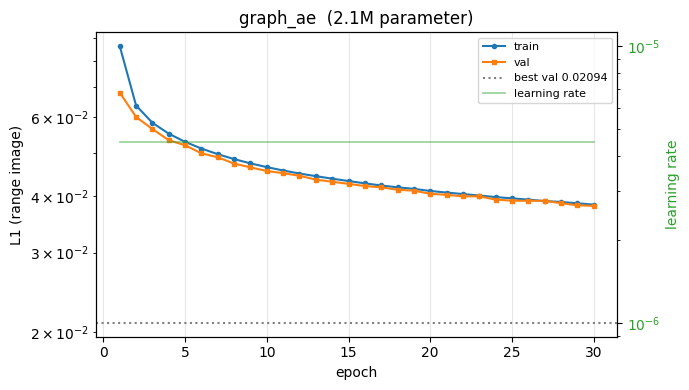

In [11]:
# A pontfelhoket eldobjuk, hogy a range image-eknek legyen helye.
drop("x_train", "x_val")
r_train, r_val = load_ranges(("train", "val"))
print(f"ranges  train {tuple(r_train.shape)}  val {tuple(r_val.shape)}  "
      f"{(r_train.numel() + r_val.numel()) * 4 / 1e9:.1f} GB")
GRAPH_LR = 4.5e-6

model = LidarAE(DDCONFIG)
hist_graph_ae, model = train_model(
    model, label="graph_ae", batch=BATCH["graph_ae"],
    train_data=r_train, val_data=r_val, epochs=EPOCHS, lr=GRAPH_LR)
plot_history(hist_graph_ae, ylabel="sulyozott L1 (range image)")


In [12]:
free_vram(model)
print("graph_ae utan:", vram())

graph_ae utan: 0.01 GB foglalt / 0.02 GB fenntartva / 8.3 GB osszes


## 6. `point_mae` — maszkolt autoencoder

train:   0%|          | 0/35037 [00:00<?, ?frame/s]

val  :   0%|          | 0/7507 [00:00<?, ?frame/s]

point_mae  (4.0M parameter, lr=0.001, batch=192, 35037 train frame, epoch 1-30)


epoch 1/30:   0%|          | 0/183 [00:00<?, ?it/s]

  epoch  1  train 3.34572  val 2.90781   spread_ratio 0.213  lr 1.00e-03  [3 perc]  *


...

  epoch 28  train 1.73616  val 1.74548   spread_ratio 0.310  lr 1.00e-03  [70 perc]  *


epoch 29/30:   0%|          | 0/183 [00:00<?, ?it/s]

  epoch 29  train 1.72961  val 1.74588   spread_ratio 0.305  lr 1.00e-03  [73 perc]


epoch 30/30:   0%|          | 0/183 [00:00<?, ?it/s]

  epoch 30  train 1.71831  val 1.73510   spread_ratio 0.301  lr 1.00e-03  [75 perc]  *
  kesz: lidar/point_mae.ckpt  (best val 1.73510, 75.5 perc ebben a futasban)


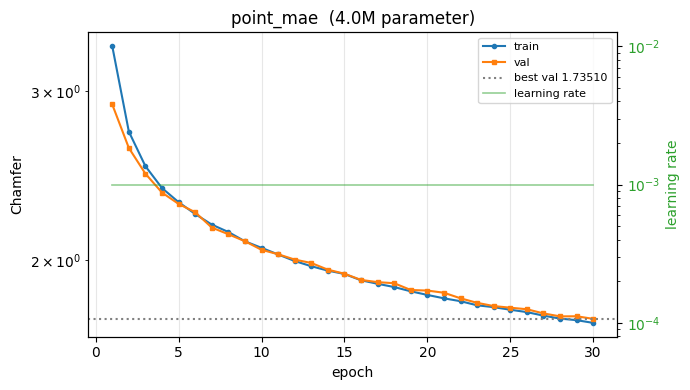

In [13]:
# Vissza a pontfelhokre.
drop("r_train", "r_val")
x_train, x_val = load_clouds(("train", "val"))

model = PointMAE()
hist_point_mae, model = train_model(
    model, label="point_mae", batch=BATCH["point_mae"],
    train_data=x_train, val_data=x_val, epochs=EPOCHS, lr=1e-3)
plot_history(hist_point_mae, ylabel="Chamfer")

In [14]:
free_vram(model)
print("point_mae utan:", vram())

point_mae utan: 0.02 GB foglalt / 2.44 GB fenntartva / 8.3 GB osszes


## 7. Osszehasonlitas

A harom loss **nem osszemerheto** egymassal (sulyozott MSE vs L1 vs Chamfer),
ezert nem a nyers szamokat hasonlitjuk, hanem:

1. a tanulasi gorbek alakjat (tanult-e egyaltalan),
2. a rekonstrukciokat (mit epit vissza),
3. a latens kihasznaltsagat (nem urult-e ki),
4. a latens idobeli simasagat (hasznalhato-e RL allapotkent).

In [15]:
# Az osszehasonlitashoz mindket reprezentacio kell, de csak a VAL es a TEST
# halmaz - azok egyutt is elfernek (50 ezer frame-nel ~8 GB).
#
# A TEST halmaz itt kerul eloszor elo: a tanitas alatt egyetlen modell sem
# latta, es egyetlen dontesunk sem tamaszkodott ra.
drop("x_train", "x_val", "r_train", "r_val")
x_val, x_test = load_clouds(("val", "test"))
r_val, r_test = load_ranges(("val", "test"))
print(f"x_val {tuple(x_val.shape)}  x_test {tuple(x_test.shape)}")
print(f"r_val {tuple(r_val.shape)}  r_test {tuple(r_test.shape)}")
print(f"osszesen {(x_val.numel() + x_test.numel() + r_val.numel() + r_test.numel()) * 4 / 1e9:.1f} GB")

val  :   0%|          | 0/7507 [00:00<?, ?frame/s]

test :   0%|          | 0/7507 [00:00<?, ?frame/s]

val  :   0%|          | 0/7507 [00:00<?, ?frame/s]

test :   0%|          | 0/7507 [00:00<?, ?frame/s]

x_val (7507, 24576, 3)  x_test (7507, 24576, 3)
r_val (7507, 1, 44, 256)  r_test (7507, 1, 44, 256)
osszesen 5.1 GB


In [ ]:
def load_model(hist):
    """Modell visszatoltese a checkpointbol.

    A hparams szurve van: ha kozben kikerult egy parameter a modellbol (pl.
    a latent_dim, amikor a bottleneck megszunt), a regi checkpoint attol meg
    betoltheto marad.
    """
    import inspect
    ck = torch.load(hist["ckpt"], map_location="cpu", weights_only=False)
    arch = ck["arch"]
    cls = {"PointMAE": PointMAE, "BEVConvAE": BEVConvAE}.get(arch)

    if cls is None:                      # LidarAE - a ddconfig kivulrol jon
        m = LidarAE(DDCONFIG)
    else:
        ok = set(inspect.signature(cls.__init__).parameters)
        hp = {k: v for k, v in (ck.get("hparams") or {}).items() if k in ok}
        m = cls(**hp)

    # A LEGJOBB sulyokat toltjuk vissza: a "state_dict" az UTOLSO allapot
    # (a folytatashoz kell), a "best_state" a legjobb epoche.
    m.load_state_dict(ck.get("best_state") or ck["state_dict"])
    return m.eval()


In [ ]:
# A futtatas sorrendjeben.
HISTORIES = [hist_bev_ae, hist_graph_ae, hist_point_mae]

# Melyik modell melyik halmazbol dolgozik. Ugyanazok a framek, csak mas
# reprezentacioban - kozos permutacioval vagtuk oket, tehat az
# osszehasonlitas ervenyes.
VAL_DATA = {"bev_ae": x_val, "graph_ae": r_val, "point_mae": x_val}
TEST_DATA = {"bev_ae": x_test, "graph_ae": r_test, "point_mae": x_test}

# A loss-ok mertekegysege. A 'val loss' oszlop NEM hasonlithato a sorok
# kozott: mindharom modell mas celfuggvenyt optimalizal.
units = ["BCE+Dice+MSE (BEV)", "sulyozott L1 (range)", "Chamfer [m^2]"]

# Eval batch: nagyobb lehet a tanitasinal, mert itt csak no_grad inferencia
# fut - nem kell tarolni az aktivaciokat a backwardhoz.
EVAL_BATCH = {"bev_ae": 512, "graph_ae": 32, "point_mae": 256}

print("Mentett checkpointok:")
for h in HISTORIES:
    print(f"  {h['ckpt']:26s} {os.path.getsize(h['ckpt']) / 1e6:6.1f} MB   "
          f"best val {h['best']:.5f}  ({h['epochs_run']} epoch, "
          f"{h['time'] / 60:.0f} perc)")

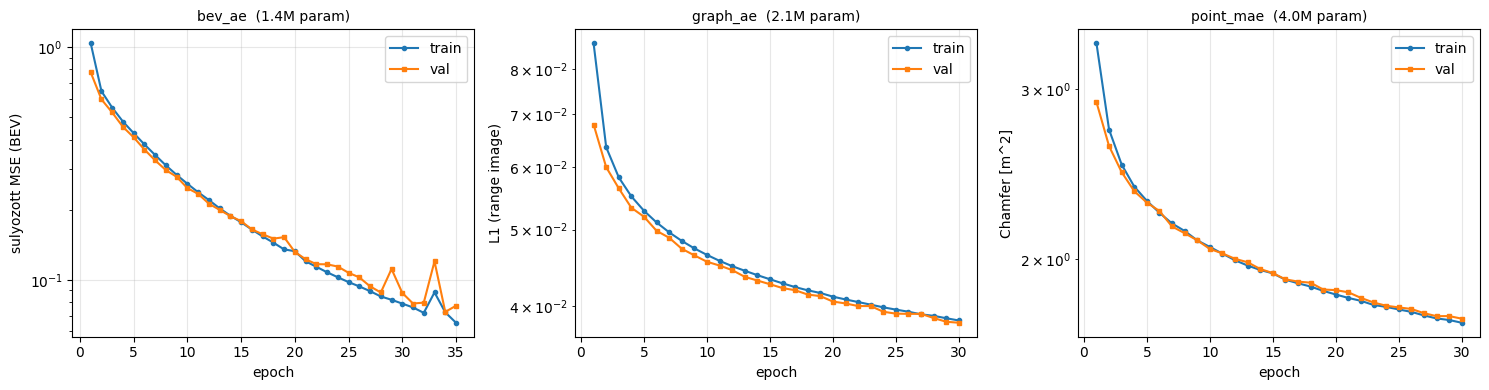

In [18]:
# --- Tanulasi gorbek egymas mellett ---
# KULON abran, mert mas a mertekegysegük - egy abrara rakva az egyik gorbe
# lelapulna a masik mellett, es nem latszana, tanul-e egyaltalan.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, h, unit in zip(axes, HISTORIES, units):
    ep = range(1, len(h["train"]) + 1)
    ax.plot(ep, h["train"], "-o", ms=3, label="train")
    ax.plot(ep, h["val"], "-s", ms=3, label="val")
    ax.set_xlabel("epoch")
    ax.set_ylabel(unit)
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
    ax.legend()
    ax.set_title(f"{h['label']}  ({h['params'] / 1e6:.1f}M param)", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# --- A VEGSO, ELFOGULATLAN MERES: a test halmaz ---
#
# A val loss-t a tanitas alatt vegig neztuk, es az alapjan valasztottuk ki a
# legjobb epochot - tehat abba mar "belelattunk". A test halmazt viszont most
# nezzuk meg eloszor, egyetlen alkalommal.
#
# Ha a test erteke kozel van a valhoz, a modell altalanosit. Ha erdemben
# rosszabb, akkor a val halmazra valasztottunk tul szorosan.
# FIGYELEM: a hist["best"] NEM mindig a teljes loss! A graph_ae-nel az
# l1_occupied-ot kovetjuk (az a hasznos szam), a tobbinel a teljes losst.
# Ezert a val-t is UGYANAZZAL a mercevel kell ujramerni, amivel a testet -
# kulonben ket kulonbozo mennyiseget hasonlitanank ossze.
test_scores, val_scores = {}, {}
for h in HISTORIES:
    m = load_model(h).to(DEVICE)
    eb = EVAL_BATCH[h["label"]]
    val_scores[h["label"]] = evaluate(m, VAL_DATA[h["label"]], eb)
    test_scores[h["label"]] = evaluate(m, TEST_DATA[h["label"]], eb)
    free_vram(m)

print(f"{'modell':12s} {'val':>10s} {'test':>10s} {'elteres':>10s}")
print("-" * 46)
for h in HISTORIES:
    va, te = val_scores[h["label"]], test_scores[h["label"]]
    print(f"{h['label']:12s} {va:10.5f} {te:10.5f} {100 * (te - va) / va:+9.1f}%")
print("\nA nagy pozitiv elteres tullanulast jelez a val halmazra.")
print("(Mindket oszlop a TELJES lossal merve, ugyanazon a modellen.)")

In [ ]:
print(f"{'modell':12s} {'val loss':>10s} {'metrika':>18s} {'latens':>9s} "
      f"{'param':>8s} {'epoch':>6s} {'perc':>6s}")
print("-" * 78)

for h, unit in zip(HISTORIES, units):
    print(f"{h['label']:12s} {h['best']:10.5f} {unit:>18s} "
          f"{np.prod(LATENT_SHAPE[h['label']]):9d} {h['params'] / 1e6:7.1f}M "
          f"{h['epochs_run']:6d} {h['time'] / 60:6.1f}")

print("\nA latens mindharomnal TERBELI jellemzoterkep, nem lapitott vektor -")
print("az RL sajat CNN feature-extractora dolgozza fel. A 'latens' oszlop az")
print("ertekek szamat mutatja, nem egy vektor hosszat.")

In [ ]:
# --- Rekonstrukciok: mit epit vissza a ket pontfelho-alapu modell? ---
#
# A point_mae a MASZKOLT patch-eket epiti vissza - a kek pontok a lathato
# resz (amit az encoder latott), a piros a rekonstrualt hianyzo resz.

n = 3
idx = np.random.choice(len(x_val), n, replace=False)
sample = x_val[idx]

m = load_model(hist_point_mae).to(DEVICE)
with torch.no_grad():
    rebuild, gt, mask, center = m(sample.to(DEVICE))
free_vram(m)

rebuild, gt, mask, center = (t.cpu() for t in (rebuild, gt, mask, center))

fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5.5))
for j in range(n):
    vis_c = center[j][~mask[j]]
    mask_c = center[j][mask[j]]
    # A patch-ek lokalis koordinatait vissza kell tolni a kozeppontjukra.
    rec_pts = (rebuild[j] + mask_c.unsqueeze(1)).reshape(-1, 3)

    ax = axes[j]
    ax.scatter(sample[j][:, 0], sample[j][:, 1], s=0.3, c="lightgray",
               linewidths=0, label="teljes felho")
    ax.scatter(vis_c[:, 0], vis_c[:, 1], s=45, c="tab:blue", marker="o",
               label=f"lathato kozeppont ({len(vis_c)})")
    ax.scatter(rec_pts[:, 0], rec_pts[:, 1], s=1.5, c="tab:red", linewidths=0,
               label=f"rekonstrualt ({len(mask_c)} patch)")
    ax.set_xlim(-51.2, 51.2)
    ax.set_ylim(-51.2, 51.2)
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    if j == 0:
        ax.set_ylabel("y [m]")
        ax.legend(fontsize=8, loc="upper right", markerscale=2)
    ax.set_title(f"point_mae rekonstrukcio #{j}", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# --- Ugyanaz 3D-ben, interaktivan ---
#
# A felulnezeten nem latszik, hogy a rekonstruktalt pontok a helyes
# MAGASSAGBAN vannak-e. Itt korbe lehet jarni: ha a piros pontok a szurke
# felho felszinen ulnek, a modell megtanulta a geometriat; ha a levegoben
# lebegnek vagy a foldbe fulnak, nem.

j = 0                                    # melyik mintat nezzuk a harombol
mask_c_j = center[j][mask[j]]
rec_pts_j = (rebuild[j] + mask_c_j.unsqueeze(1)).reshape(-1, 3)
gt_pts_j = (gt[j] + mask_c_j.unsqueeze(1)).reshape(-1, 3)

show_3d(
    sample[j],
    title=f"point_mae rekonstrukcio 3D  -  {len(mask_c_j)} maszkolt patch",
    extra=[
        (gt_pts_j, f"valodi (maszkolt) pontok", "limegreen", 2.0),
        (rec_pts_j, f"rekonstrualt pontok", "red", 2.0),
        (center[j][~mask[j]], "lathato patch-kozeppontok", "royalblue", 4.0),
    ],
)

In [ ]:
# --- bev_ae: a BEV jellemzoterkep es a rekonstrukcioja ---
#
# A harom csatornabol az occupancy a legolvashatobb: hol van egyaltalan pont.
m = load_model(hist_bev_ae).to(DEVICE)
# A kiterjedes a modell sajat hatosugarabol, nem beegetve.
_r = m.hparams.pc_range
EXT = [-_r, _r, -_r, _r]
with torch.no_grad():
    bev = m.to_bev(sample.to(DEVICE))
    rec = m.decode(m.encode_bev(bev))
bev, rec = bev.cpu(), rec.cpu()
free_vram(m)

fig, axes = plt.subplots(2, n, figsize=(5 * n, 9))
for j in range(n):
    axes[0, j].imshow(bev[j, 0], cmap="gray_r", origin="lower", vmin=0, vmax=1,
                      extent=EXT)
    axes[0, j].set_title(f"eredeti occupancy #{j}", fontsize=10)
    axes[1, j].imshow(rec[j, 0], cmap="gray_r", origin="lower", vmin=0, vmax=1,
                      extent=EXT)
    # Csak az occupancy csatorna hibaja - az a szemmel is ellenorizheto.
    axes[1, j].set_title(
        f"rekonstrukcio  (occ. L1 {(rec[j, 0] - bev[j, 0]).abs().mean():.4f})",
        fontsize=10)
    for i in (0, 1):
        axes[i, j].set_xlabel("x [m]")
axes[0, 0].set_ylabel("y [m]")
axes[1, 0].set_ylabel("y [m]")
plt.tight_layout()
plt.show()

# CSATORNANKENTI COLLAPSE-FIGYELO.
#
# Ha a 'rec std' nagysagrendekkel a 'cel std' alatt van, a halo az adott
# csatornat KIATLAGOLTA: konstanst josol, nem rekonstrual. Pontosan ez a hiba
# tette a regi (tanult pillar-encoderes) bev_ae-t hasznalhatatlanna, es a
# nyers loss-ertek NEM mutatja meg. A tanitas vegen a ket oszlopnak kozel kell
# lennie egymashoz.
print(f"{'csatorna':12s} {'cel std':>9s} {'rec std':>9s} {'MSE':>9s}")
# A lista a BEV tenyleges csatornaszamara vagva - igy ha megint valtozik
# a BEV, ez a cella nem szall el IndexError-ral.
for c, name in enumerate(["occupancy", "z_max", "z_min"][:bev.shape[1]]):
    print(f"{name:12s} {float(bev[:, c].std()):9.4f} "
          f"{float(rec[:, c].std()):9.4f} "
          f"{float(F.mse_loss(rec[:, c], bev[:, c])):9.5f}")

In [ ]:
# --- graph_ae: a range image es a rekonstrukcioja ---
#
# A range image mar kesz a `r_val`-ban, a TELJES felhobol szamolva.
# A kep 44x256: az eg le van vagva (fov_up -0.9 fok), igy ~90%-ban tele van.
m = load_model(hist_graph_ae).to(DEVICE)
ri_in = r_val[idx].to(DEVICE).float()
# Framenkent, mert a dekoder memoriaigenyes (lasd a 6. szekcio megjegyzeset).
with torch.no_grad():
    ri_rec = torch.cat([m(ri_in[i:i + 1]) for i in range(len(ri_in))])
ri_in, ri_rec = ri_in.cpu(), ri_rec.cpu()
free_vram(m)

fig, axes = plt.subplots(2 * n, 1, figsize=(14, 2.4 * 2 * n))
for j in range(n):
    axes[2 * j].imshow(ri_in[j, 0], cmap="magma", aspect="auto", vmin=-1, vmax=1)
    axes[2 * j].set_title(
        f"eredeti range image #{j}  "
        f"(kitoltottseg {(ri_in[j] > -0.999).float().mean() * 100:.1f}%)",
        fontsize=10)
    axes[2 * j].set_ylabel("lidar csatorna")
    axes[2 * j + 1].imshow(ri_rec[j, 0], cmap="magma", aspect="auto", vmin=-1, vmax=1)
    axes[2 * j + 1].set_title(
        f"rekonstrukcio  (L1 {F.l1_loss(ri_rec[j], ri_in[j]):.4f})", fontsize=10)
    axes[2 * j + 1].set_ylabel("lidar csatorna")
axes[-1].set_xlabel("azimut")

plt.tight_layout()
plt.show()

In [ ]:
# --- Kihasznaljak-e a modellek a jellemzoteret? ---
#
# A modellek mar NEM vektort adnak, hanem terbeli jellemzoterkepet:
#
#   bev_ae     (256, 8, 8)     = 16384
#   graph_ae   (16, 16, 128)   = 32768
#   point_mae  (128, 192)      = 24576  (tokenek)
#
# Ezert a vizsgalat is CSATORNA-szintu lett: egy csatorna akkor halott, ha a
# terkep egeszen at alig valtozik framerol framere. A telitettseg fogalma
# elesett a tanh-hal egyutt.

n_sample = min(2000, len(x_val))
sidx = np.random.choice(len(x_val), n_sample, replace=False)

fig, axes = plt.subplots(1, len(HISTORIES), figsize=(6 * len(HISTORIES), 3.6))

for k, h in enumerate(HISTORIES):
    m = load_model(h).to(DEVICE)
    data = VAL_DATA[h["label"]][sidx]
    eb = EVAL_BATCH[h["label"]]

    # Csatornankenti atlag framenkent: (N, C). A terbeli atlagolas azert kell,
    # hogy a kulonbozo alaku terkepek osszemerhetok legyenek.
    zs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(data), eb), desc=h["label"], leave=False):
            xb = data[i:i + eb].to(DEVICE).float()
            z = m.encode(xb)
            # (B, C, H, W) -> (B, C)  vagy  (B, G, D) -> (B, D)
            dims = tuple(range(2, z.dim())) if z.dim() > 2 else ()
            zs.append((z.mean(dim=dims) if dims else z).cpu())
    z = torch.cat(zs).float().numpy()
    free_vram(m)

    std = z.std(axis=0)
    # Halott: a csatorna szorasa a LEGNAGYOBB csatorna 1%-a alatt van.
    dead = int((std < 0.01 * std.max()).sum())

    ax = axes[k]
    ax.bar(range(len(std)), np.sort(std)[::-1], width=1.0)
    ax.set_title(f"{h['label']}  ({len(std)} csatorna)\n"
                 f"{dead} halott csatorna", fontsize=10)
    ax.set_xlabel("csatorna (szoras szerint rendezve)")
    ax.set_ylabel("szoras (terbeli atlag)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("VRAM:", vram())


In [ ]:
# --- Latens simasag: idoben szomszedos framek ---
#
# MIERT SZAMIT: az RL agent a latenst allapotkent latja. Ha ket egymast koveto
# frame (0.05 s kulonbseg) latense nagyot ugrik, az agent zajt lat, nem
# allapotot - a tanulas instabil lesz.
#
# A mero: a szomszedos framek latens-tavolsaga, elosztva a VELETLENSZERUEN
# valasztott parok tavolsagaval. Minel kisebb, annal simabb.
#   ~0.0 : tokeletesen sima
#   ~1.0 : a szomszedos frame ugyanolyan tavol van, mint egy veletlen - a
#          latens gyakorlatilag zaj

# Idorendben egymast koveto framek kellenek, a `clouds`/`ranges` viszont mar
# meg van keverve - ezert UJRA betoltunk nehany keveretlen szakaszt.
#
# Tobb helyrol: egyetlen szakasz lehet veletlenul egy piros lampanal allo
# auto, ahol minden frame majdnem azonos, es akkor minden modell "simanak"
# tunne.
SEG_LEN, N_SEG = 256, 4
all_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.npy")))
starts = np.linspace(0, len(all_paths) - SEG_LEN - 1, N_SEG).astype(int)

seg_clouds, seg_ranges = [], []
for s in starts:
    seg_paths = all_paths[s:s + SEG_LEN]
    c = np.empty((len(seg_paths), N_POINTS, 3), dtype=np.float32)
    r = np.empty((len(seg_paths), *points_to_range_image(np.load(seg_paths[0])).shape),
                 dtype=np.float32)
    for i, p in enumerate(seg_paths):
        pts = np.load(p)
        # Ugyanaz a ket reprezentacio, mint a tanitasnal: a range image a
        # TELJES felhobol, a pontfelho leritkitva.
        r[i] = points_to_range_image(pts).astype(np.float16)
        rng = np.random.default_rng(i)
        sel = rng.choice(len(pts), N_POINTS, replace=len(pts) < N_POINTS)
        c[i] = pts[sel]
    seg_clouds.append(torch.from_numpy(c))
    seg_ranges.append(torch.from_numpy(r))

SEG_DATA = {"point_mae": seg_clouds, "bev_ae": seg_clouds,
            "graph_ae": seg_ranges}

print(f"{N_SEG} szakasz x {SEG_LEN} frame, a felvetel kulonbozo pontjairol\n")
print(f"{'modell':12s} {'szomszed tav':>14s} {'veletlen tav':>14s} {'arany':>8s}")
print("-" * 52)

smooth = {}
for h in HISTORIES:
    m = load_model(h).to(DEVICE)
    eb = EVAL_BATCH[h["label"]]

    per_seg = []
    for seg in SEG_DATA[h["label"]]:
        zs = []
        with torch.no_grad():
            for i in range(0, len(seg), eb):
                xb = seg[i:i + eb].to(DEVICE).float()
                zs.append(m.encode(xb).flatten(1).cpu())
        z = torch.cat(zs)
        # Szomszedos framek tavolsaga.
        d_neigh = float((z[1:] - z[:-1]).norm(dim=1).mean())
        # Veletlen parok tavolsaga - ez a "skala", amihez viszonyitunk.
        pp = torch.randperm(len(z))
        d_rand = float((z[pp] - z).norm(dim=1).mean())
        per_seg.append((d_neigh, d_rand, d_neigh / d_rand))
    free_vram(m)

    d_neigh = float(np.mean([x[0] for x in per_seg]))
    d_rand = float(np.mean([x[1] for x in per_seg]))
    ratio = float(np.mean([x[2] for x in per_seg]))
    smooth[h["label"]] = ratio

    print(f"{h['label']:12s} {d_neigh:14.3f} {d_rand:14.3f} {ratio:8.3f}")

best = min(smooth, key=smooth.get)
print(f"\nLEGSIMABB latens: {best}  (arany {smooth[best]:.3f})")

# Ertelmezes. Ha MINDEN modell 0.9 folott van, akkor egyik latens sem sima -
# ilyenkor a rangsor nem sokat jelent, mert csak zajt rangsorol.
if min(smooth.values()) > 0.9:
    print("\nFIGYELEM: mindharom arany 0.9 folott van, tehat egyik latens sem")
    print("simabb annal, mintha veletlen frameket parositanank. Ez alultanitas")
    print("jele - emeld az EPOCHS erteket, vagy nezd meg a gorbeket.")

## 8. Osszefoglalas - mi lett a harom modellbol

Mindharom encoder **terbeli jellemzoterkepet** ad, nem lapitott vektort. Az RL
sajat CNN feature-extractora dolgozza fel oket.

| modell | encode() kimenet | ertek | param | betanitva |
|---|---|---|---|---|
| `bev_ae` | (256, 8, 8) racs | 16 384 | 1.4M | 35 epoch |
| `graph_ae` | (16, 11, 32) racs | 5 632 | 2.1M | 30 epoch |
| `point_mae` | (128, 192) **halmaz** | 24 576 | 4.0M | 30 epoch |

### Minoseg - mindegyik a SAJAT mercejen

| modell | metrika | eredmeny | viszonyitas |
|---|---|---|---|
| `bev_ae` | occupancy precision / recall | **0.986 / 0.983** | a kiindulasi 0.594 / 0.974 |
| | magassaghiba (metszeten) | **0.430 m** | a kiindulasi 0.535 m |
| `graph_ae` | `l1_occupied` | **0.021** | a kiindulasi 0.106 (5x jobb) |
| `point_mae` | Chamfer | **1.724** | trivialis patch-atlag: 4.375 (**+60.6%**) |

### Ami a leginkabb szamitott

**1. A bottleneck kivetele.** Mindharom modellnel egy `Linear` par lapitotta
a terbeli kimenetet egyetlen vektorra, es MERVE ez dobta el a minoseg nagy
reszet. A `bev_ae`-n: precision 0.82 (256 dim latens) vs **0.94** (nincs
szukites) - es a latens MERETE nem szamitott (256 es 2048 kozott nincs
kulonbseg), csak a terbeli szerkezet elvesztese.

**2. A loss szerkezete.** A `bev_ae` regi lossa mind az ot csatornat egyetlen
sulyozott MSE-be tette; a kimeneti reteg gradiense 0.00089 volt, BCE-vel
**0.0528** (60x). A `graph_ae`-nel a teljes L1 ~85%-a az URES teruletekbol
jott - a sulyozas (`empty_weight=0.25`) tette a gradienst a geometriara.

**3. A learning rate.** A `graph_ae` 1e-4-gyel oszcillalt; az eredeti
TopoLiDM config **4.5e-6**-ot ir elo - huszonketszer kisebbet. Ezzel a loss
monoton csokken, egyetlen visszaugras nelkul.

**4. A felbontas a SZENZORHOZ.** A TopoLiDM 64x1024-e a KITTI-re valo
(~120 000 pont/frame); a mi lidarunk 28 368-at ad, a suruseg 24%-at. Az eg
levagasaval (`fov_up` -0.9 fok) es 44x256-os raccsal a kitoltottseg
61% -> **90.6%**, a geometriai hiba pedig 0.363 -> **0.310 m** - vagyis
JOBB lett, pedig a pontok 57%-a eldobodik. Ok: a range image cellankent a
legkozelebbi pontot tartja meg, amit eldob, az mogotte van.

### Az RL-hez

Az encoderek determinisztikusak, minden csatorna el, a kulonbozo jelenetek
latense szetvalik (nincs osszecsuszas).

**Idobeli simasag: 0.58-0.64** (szomszedos framek latens-tavolsaga a
veletlen parokehoz kepest). Ez mindket kesz modellnel hasonlo, tehat nem
alultanitottsag, hanem a lidar mintaveteli zaja. Az RL-ben ezert
**frame-stacking** ajanlott: 2-4 egymast koveto latens osszefuzve. Ez
kisimitja a zajt, es mozgas-informaciot is ad, amit egyetlen frame nem
hordoz.

A `point_mae` kimenete **halmaz**, nem racs: a 128 token sorrendje veletlen
(FPS + Transformer, mindketto permutacio-fuggetlen). Oda pontonkenti MLP +
pooling vagy attention-fej kell, nem sima CNN - es a patch-kozeppontok is
(`encode(x, return_centers=True)`), kulonben a halmaz pozicio-informacio
nelkul marad.
